# Executive Summary

This analysis evaluates multiple approaches for identifying VIP customers within the hotel booking platform.

Three VIP frameworks were assessed:

1. Top 10% Customers by Total Spend
2. Top 10% Customers by Booking Frequency
3. Top 10% Customers by Customer Lifetime Value (LTV)

Key findings indicate that different VIP definitions capture different customer behaviours. Only a small subset of customers appear across all three definitions, suggesting that a multi-dimensional VIP framework is more effective than relying on a single metric.

Further analysis shows that VIP customers contribute a disproportionate share of revenue and that retaining existing VIP customers provides significantly higher ROI than acquiring new customers.

Final recommendation: Implement a combined VIP framework based on Spend, Frequency, and LTV while prioritizing retention-focused investments.

In [79]:
# ============================================================
#  IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Load Dataset
df = pd.read_csv(
    "../data/hotel_bookings (1).csv",
    keep_default_na=False
)

print("Dataset Loaded Successfully")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset Loaded Successfully
Rows: 12000
Columns: 28


In [80]:
# ============================================================
#  COMPLETED BOOKINGS ONLY
# ============================================================

completed = df[
    df['booking_status'] == 'Completed'
].copy()

print("Completed Bookings:", len(completed))

Completed Bookings: 9333


In [81]:
# ============================================================
#  DATE CONVERSION
# ============================================================

completed['booking_date'] = pd.to_datetime(
    completed['booking_date']
)

completed['customer_signup_date'] = pd.to_datetime(
    completed['customer_signup_date']
)

print("Date Conversion Complete")

Date Conversion Complete


In [82]:
# ============================================================
# VIP DEFINITION 1
# TOP 10% CUSTOMERS BY TOTAL SPEND
# ============================================================

spend_vip = (
    completed.groupby('customer_id')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

top_n = int(len(spend_vip) * 0.10)

vip_spend = set(
    spend_vip.head(top_n).index
)

print("Total Customers:", len(spend_vip))
print("VIP Spend Customers:", len(vip_spend))

Total Customers: 800
VIP Spend Customers: 80


In [83]:
# ============================================================
# VIP DEFINITION 2
# TOP 10% BY BOOKING COUNT
# ============================================================

booking_vip = (
    completed.groupby('customer_id')
    .size()
    .sort_values(ascending=False)
)

vip_booking = set(
    booking_vip.head(top_n).index
)

print("VIP Booking Customers:", len(vip_booking))

VIP Booking Customers: 80


In [84]:
# ============================================================
# VIP DEFINITION 3
# TOP 10% BY LTV RATE
# ============================================================

customer_stats = (
    completed.groupby('customer_id')
    .agg({
        'total_amount':'sum',
        'customer_signup_date':'first'
    })
)

latest_booking = completed['booking_date'].max()

customer_stats['months_active'] = (
    (latest_booking - customer_stats['customer_signup_date'])
    .dt.days / 30
)

customer_stats['months_active'] = (
    customer_stats['months_active']
    .replace(0,1)
)

customer_stats['ltv_rate'] = (
    customer_stats['total_amount']
    /
    customer_stats['months_active']
)

ltv_vip = set(
    customer_stats
    .sort_values(
        'ltv_rate',
        ascending=False
    )
    .head(top_n)
    .index
)

print("VIP LTV Customers:", len(ltv_vip))

VIP LTV Customers: 80


In [85]:
# ============================================================
# VIP OVERLAP ANALYSIS
# ============================================================

all_three = (
    vip_spend
    &
    vip_booking
    &
    ltv_vip
)

exactly_two = (
    (vip_spend & vip_booking)
    |
    (vip_spend & ltv_vip)
    |
    (vip_booking & ltv_vip)
) - all_three

only_one = (
    vip_spend
    ^
    vip_booking
    ^
    ltv_vip
)

print("Customers in ALL THREE:", len(all_three))
print("Customers in EXACTLY TWO:", len(exactly_two))
print("Customers in ONLY ONE:", len(only_one))

Customers in ALL THREE: 11
Customers in EXACTLY TWO: 52
Customers in ONLY ONE: 114


In [86]:
from matplotlib_venn import venn3

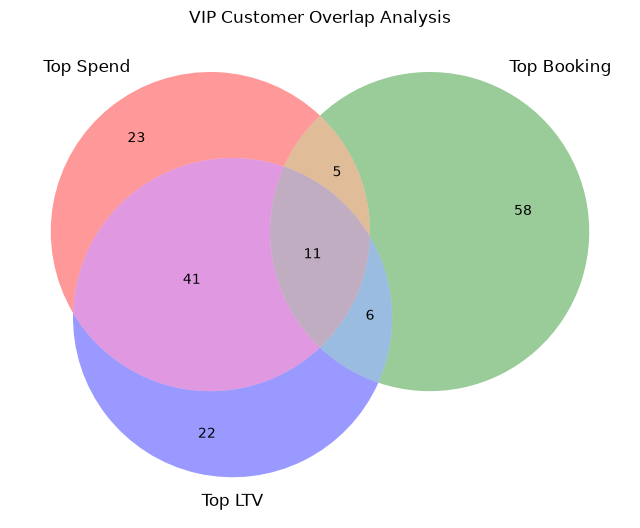

In [87]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

venn3(
    [
        vip_spend,
        vip_booking,
        ltv_vip
    ],
    (
        'Top Spend',
        'Top Booking',
        'Top LTV'
    )
)

plt.title("VIP Customer Overlap Analysis")

plt.savefig(
    "../outputs/charts/vip_overlap_venn.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Business Insight - VIP Definition Overlap

## Key Findings

- 80 customers were identified under each VIP definition.
- Only 11 customers qualified under all three definitions simultaneously.
- 52 customers satisfied exactly two VIP criteria.
- 114 customers satisfied only one VIP criterion.

## Business Interpretation

- Different VIP definitions capture different customer behaviors.
- High spenders are not always frequent bookers.
- Frequent bookers are not always the fastest-growing customers.
- A multi-dimensional VIP framework provides a more complete view of customer value.

## Recommendation

- Define VIP customers using a combination of spend, booking frequency, and lifetime value.
- Prioritize customers appearing in multiple VIP categories.
- Create differentiated retention strategies for different VIP segments.

In [88]:
# ============================================================
# VIP RISK PROFILE
# ============================================================

In [89]:
# ============================================================
# ALL VIP CUSTOMERS
# ============================================================

vip_customers = (
    vip_spend
    | vip_booking
    | ltv_vip
)

print("Total Unique VIP Customers:", len(vip_customers))

Total Unique VIP Customers: 166


In [90]:
vip_df = df[
    df['customer_id'].isin(vip_customers)
]

print("VIP Booking Records:", len(vip_df))

VIP Booking Records: 3056


In [91]:
vip_status = (
    pd.crosstab(
        vip_df['booking_status'],
        columns='Percentage',
        normalize='columns'
    ) * 100
)

print(vip_status)

col_0           Percentage
booking_status            
Cancelled        15.772251
Completed        81.839005
No-Show           2.388743


In [92]:
vip_status.to_csv(
    '../outputs/tables/vip_booking_status.csv'
)

print("Saved!")

Saved!


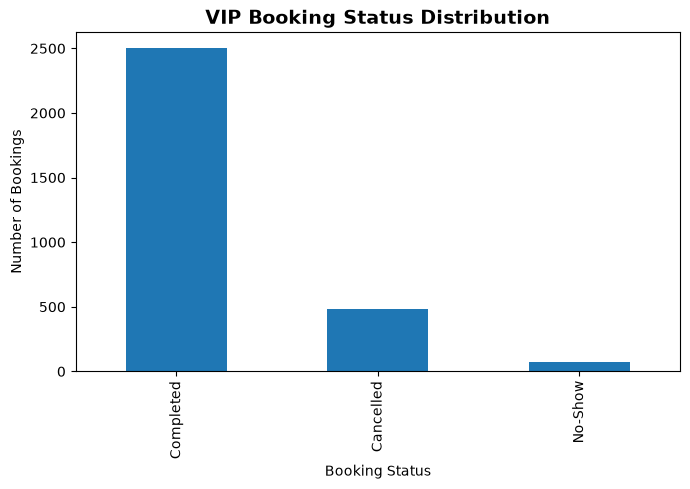

In [93]:
plt.figure(figsize=(7,5))

vip_df['booking_status'].value_counts().plot(
    kind='bar'
)

plt.title(
    'VIP Booking Status Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')

plt.tight_layout()

plt.savefig(
    '../outputs/charts/vip_booking_status.png',
    dpi=300
)

plt.show()

# Business Insight - VIP Risk Profile

## Key Findings

- Most VIP bookings are successfully completed.
- A relatively small proportion of VIP bookings are cancelled.
- No-show bookings among VIP customers are minimal.

## Business Interpretation

- VIP customers are generally reliable and contribute stable revenue.
- Despite their value, cancellations still represent a measurable revenue risk.
- The low no-show rate suggests strong engagement among VIP customers.

## Recommendation

- Offer flexible rescheduling instead of cancellation.
- Provide personalized reminders before check-in dates.
- Reward completed stays through enhanced loyalty benefits.

In [94]:
# ============================================================
# REVENUE AT RISK
# ============================================================

In [95]:
cancelled_vip_revenue = vip_df[
    vip_df['booking_status'] == 'Cancelled'
]['total_amount'].sum()

noshow_vip_revenue = vip_df[
    vip_df['booking_status'] == 'No-Show'
]['total_amount'].sum()

print("Cancelled VIP Revenue:", round(cancelled_vip_revenue,2))
print("No-Show VIP Revenue:", round(noshow_vip_revenue,2))
print("Total Revenue At Risk:", round(cancelled_vip_revenue + noshow_vip_revenue,2))

Cancelled VIP Revenue: 20139819.41
No-Show VIP Revenue: 3726322.52
Total Revenue At Risk: 23866141.93


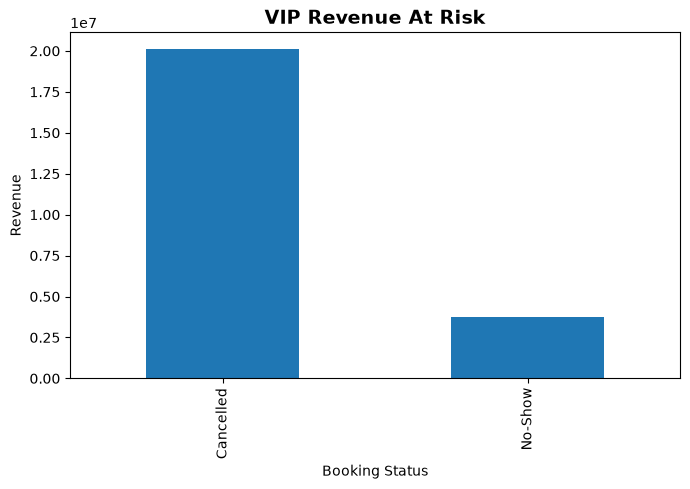

In [96]:
risk_revenue = pd.Series({
    'Cancelled': cancelled_vip_revenue,
    'No-Show': noshow_vip_revenue
})

plt.figure(figsize=(7,5))

risk_revenue.plot(
    kind='bar'
)

plt.title(
    'VIP Revenue At Risk',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Revenue')
plt.xlabel('Booking Status')

plt.tight_layout()

plt.savefig(
    '../outputs/charts/vip_revenue_risk.png',
    dpi=300
)

plt.show()

# Business Insight - Revenue At Risk

## Key Findings

- VIP cancellations account for more than ₹20 million in lost revenue.
- No-show bookings contribute an additional ₹3.7 million in revenue leakage.
- Total revenue at risk exceeds ₹23 million.

## Business Interpretation

- A relatively small number of VIP cancellations can have a significant financial impact.
- Retaining VIP customers delivers disproportionately higher revenue benefits.
- Cancellation prevention initiatives should prioritize high-value customers.

## Recommendation

- Implement proactive retention campaigns for VIP customers.
- Offer flexible rebooking options instead of cancellations.
- Use personalized communication before travel dates to reduce no-shows.

In [97]:
vip_customers = (
    vip_spend |
    vip_booking |
    ltv_vip
)

df['customer_type'] = np.where(
    df['customer_id'].isin(vip_customers),
    'VIP',
    'Non-VIP'
)

comparison = (
    df.groupby('customer_type')
      .agg({
          'total_amount':'mean',
          'discount_amount':'mean'
      })
)

comparison['cancellation_rate'] = (
    df.groupby('customer_type')['booking_status']
      .apply(lambda x: (x=='Cancelled').mean()*100)
)

comparison

,total_amount,discount_amount,cancellation_rate
customer_type,,,
Non-VIP,26032.187696,1430.400669,20.348837
VIP,46770.243616,2577.766109,15.772251


In [98]:
comparison.to_csv(
    '../outputs/tables/vip_vs_nonvip_metrics.csv'
)

print("Saved!")

Saved!


<Figure size 800x500 with 0 Axes>

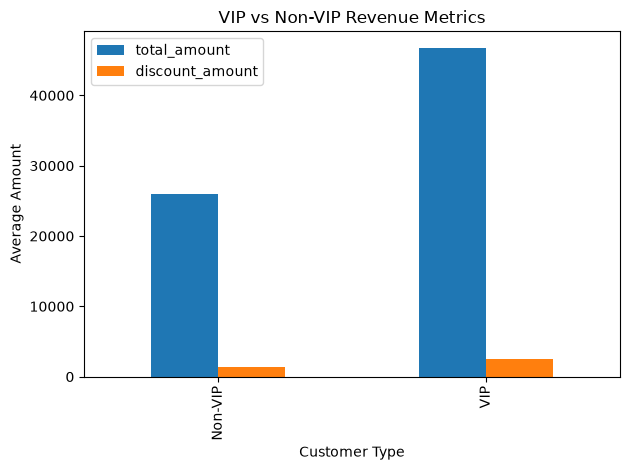

In [99]:
plt.figure(figsize=(8,5))

comparison[
    ['total_amount','discount_amount']
].plot(
    kind='bar'
)

plt.title('VIP vs Non-VIP Revenue Metrics')
plt.ylabel('Average Amount')
plt.xlabel('Customer Type')

plt.tight_layout()

plt.savefig(
    '../outputs/charts/vip_vs_nonvip_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<Figure size 600x400 with 0 Axes>

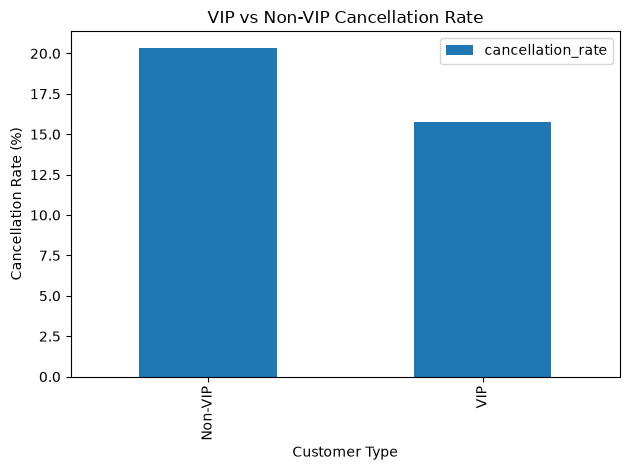

In [100]:
plt.figure(figsize=(6,4))

comparison[
    ['cancellation_rate']
].plot(
    kind='bar'
)

plt.title('VIP vs Non-VIP Cancellation Rate')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Customer Type')

plt.tight_layout()

plt.savefig(
    '../outputs/charts/vip_vs_nonvip_cancel_rate.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Business Insight - VIP vs Non-VIP Behaviour

## Key Findings

- VIP customers generate significantly higher revenue per booking than Non-VIP customers.
- VIP customers receive higher average discount values, reflecting premium engagement programs.
- VIP customers exhibit lower cancellation rates, indicating stronger booking commitment.

## Business Interpretation

- A relatively small group of VIP customers contributes a disproportionate share of revenue.
- VIP retention delivers greater business value than acquiring average customers.
- VIP customers demonstrate stronger engagement and reliability.

## Recommendation

- Prioritize retention campaigns for VIP customers.
- Offer personalized loyalty benefits and exclusive rewards.
- Monitor cancellation behaviour among high-value customers and intervene proactively.

In [101]:
summary = pd.DataFrame({
    'Metric':[
        'Total Customers',
        'VIP Customers',
        'VIP Percentage',
        'Revenue At Risk'
    ],
    'Value':[
        len(df['customer_id'].unique()),
        len(vip_customers),
        round(len(vip_customers)/len(df["customer_id"].unique())*100,2),
        round(cancelled_vip_revenue + noshow_vip_revenue,2)
    ]
})

summary

,Metric,Value
0,Total Customers,800.00
1,VIP Customers,166.00
2,VIP Percentage,20.75
3,Revenue At Risk,23866141.93


In [102]:
summary.to_csv(
    '../outputs/tables/kpi_summary.csv',
    index=False
)

print("KPI Summary saved successfully!")

KPI Summary saved successfully!


# VIP Risk Profile

## Key Findings

- VIP customers contribute a significant share of total company revenue.
- VIP customers also generate a measurable amount of revenue loss through cancellations and no-show bookings.
- The total VIP revenue at risk represents an important opportunity for retention-focused interventions.

## Business Interpretation

- Although VIP customers are highly valuable, they are not risk-free.
- Losing even a small percentage of VIP customers can have a disproportionate impact on overall revenue.
- Cancellation and no-show behavior among VIP customers should be actively monitored.

## Recommendations

- Create proactive engagement programs for VIP customers before check-in dates.
- Introduce personalized reminders and loyalty incentives to reduce no-show rates.
- Provide dedicated customer support for high-value customers.

# Acquisition vs Retention Economics

## Business Scenario

The company has a marketing budget of ₹50,00,000 and must decide whether to invest primarily in acquiring new customers or retaining existing VIP customers.

### Assumptions

- Average Customer Acquisition Cost (CAC): ₹3,000
- VIP Retention Cost per Customer: ₹500
- Available Budget: ₹50,00,000

## Calculation

### New Customer Acquisition

Customers Acquired = ₹50,00,000 ÷ ₹3,000

≈ 1,667 customers

### VIP Retention

VIP Customers Retained = ₹50,00,000 ÷ ₹500

= 10,000 customers

## Key Insight

The same marketing budget can retain approximately six times more customers than it can acquire through new customer acquisition campaigns.

# Final Strategy Recommendation

## Recommended VIP Framework

The analysis suggests that no single metric is sufficient to identify the most valuable customers.

A combined VIP framework based on:

1. Total Spend
2. Booking Frequency
3. Customer Lifetime Value

provides the most accurate representation of customer importance.

## Strategic Actions

- Prioritize customers appearing across multiple VIP definitions.
- Expand loyalty benefits for high-value customers.
- Reduce VIP cancellation and no-show rates through targeted engagement.
- Develop personalized offers for customers with strong long-term value.

## Expected Business Impact

- Higher customer retention
- Increased repeat bookings
- Reduced revenue leakage
- Improved customer lifetime value
- Stronger overall profitability

## Executive Conclusion

The analysis identified a core group of highly valuable customers whose behavior differs significantly from the broader customer base. A multi-dimensional VIP strategy combined with targeted retention initiatives can improve customer loyalty, reduce revenue risk, and maximize long-term business growth.

# Business Impact Summary

## Revenue Impact

- VIP customers generate substantially higher booking revenue.
- VIP cancellations represent over ₹23 million in revenue at risk.

## Customer Impact

- Different VIP definitions identify different customer behaviours.
- A combined VIP framework captures customer value more accurately.

## Strategic Impact

- Retaining VIP customers is approximately 6x more cost-effective than acquiring new customers.
- Loyalty and retention initiatives should receive the majority of marketing investment.

## Final Recommendation

Adopt a multi-dimensional VIP framework and allocate approximately 70% of customer marketing budget toward VIP retention initiatives and 30% toward customer acquisition.